# Notebook n°8: Milestone 3 (M3) Multivariate Audio↔OEP Coupling (CCA + PLS)

**Pipeline stage:** Milestone 3 (M3), the multivariate follow-up to the pairwise correlations of notebook n°3. Instead of one acoustic feature against one OEP feature, we ask which *combination* of audio features couples to which *combination* of respiratory features (CCA), and whether the whole audio block predicts the rib-cage share `%RC` (PLS).

**Script reproduced:** `scripts/analyze_multivariate_coupling.py`.

Audio block (16): `f0`, `energy`, `spectral_centroid`, `mfcc_0..12`. OEP block (3): `delta_vcw`, `flow_cw`, `pct_rc`. Voiced frames from sustained phonation are z-scored *within subject* (so the coupling is the calibration-free within-subject signal), the glissando `a_7` is excluded, and every number is cross-validated by subject.

> ⚠️ Requires scikit-learn.

**Summary.**\
Moving beyond pairwise Pearson (the supervisors' multivariate ask): CCA finds the audio-combination and OEP-combination with maximal correlation; PLS predicts `%RC` from the whole audio block. Both run on within-subject z-scored voiced frames from sustained phonation (glissando `a_7` excluded), per demographic stratum, cross-validated by subject.\
The audio↔OEP coupling is real but low-dimensional: the first canonical correlation is ≈ 0.39 under subject-CV (in-sample ≈ 0.41), barely above the best single feature pair (energy↔volume ≈ 0.36).\
It is carried by spectral level (MFCC-0, energy), not pitch, echoing the FRC-state classifier in notebook n°6.\
Audio → %RC prediction is weakly positive (CV R² ≈ 0.06 overall, up to ≈ 0.10 in some strata), a small gain over the per-feature regression in notebook n°5.\
Take-away: the audio readout of respiratory state is a modest, shared loudness/spectral-level signal; a large hidden linear coupling is unlikely.

## 0. Setup
Build the within-subject z-scored frame matrix once (sustained phonation, glissando excluded).

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / "pneumophonic_analysis").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / "scripts"))

from analyze_multivariate_coupling import (build_frames, cca_eval, pls_cv,
                                           stratum_index, AUDIO, OEP, STRATA_ORDER)
from analyze_l3_stratified import load_metadata
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

META = REPO / "data_root" / "healthy_subjects" / "subjects_metadata.csv"
PAIRED = REPO / "data_target" / "healthy_subjects" / "paired"
F = build_frames(PAIRED, load_metadata(META))
print(f"{len(F):,} voiced frames (sustained, a_7 excluded) | {F['subject_id'].nunique()} subjects")

105,918 voiced frames (sustained, a_7 excluded) | 37 subjects


## 1. CCA: symmetric audio↔OEP coupling, per stratum
Sustained phonation, within-subject z-scored. First canonical correlation, in-sample vs subject-held-out CV.

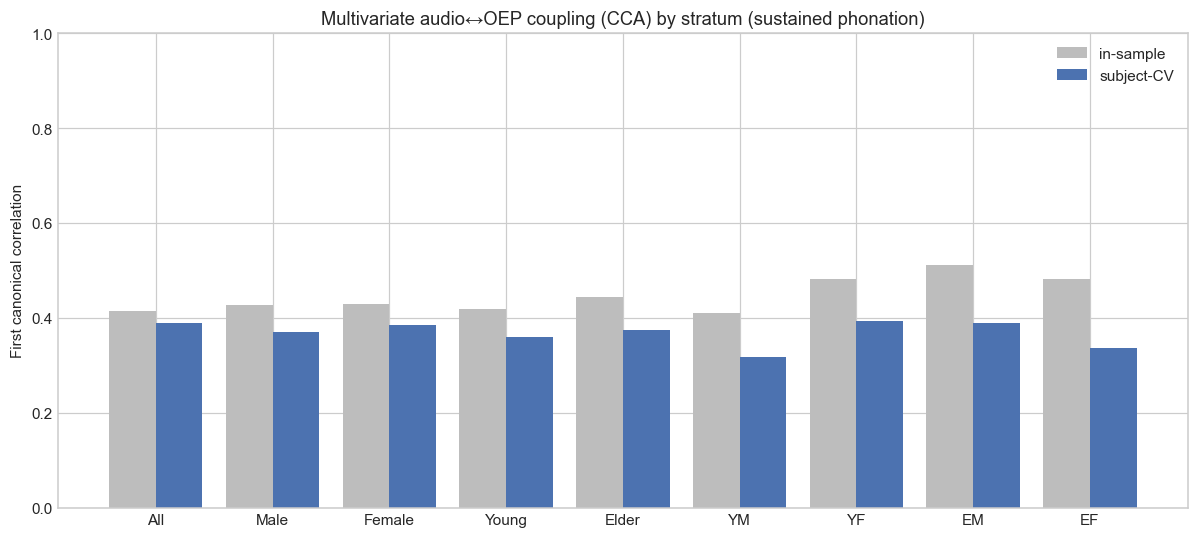

subject-CV canonical r: {'All': 0.388, 'Male': 0.37, 'Female': 0.385, 'Young': 0.36, 'Elder': 0.374, 'YM': 0.318, 'YF': 0.394, 'EM': 0.39, 'EF': 0.337}


In [2]:
cca_res = {s: cca_eval(F, stratum_index(F, s)) for s in STRATA_ORDER}
cca_res = {s: r for s, r in cca_res.items() if r is not None}
strata = list(cca_res); x = np.arange(len(strata)); w = 0.4
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, [cca_res[s]['r_in'] for s in strata], w, label='in-sample', color='#bdbdbd')
ax.bar(x + w/2, [cca_res[s]['r_cv'] for s in strata], w, label='subject-CV', color='#4c72b0')
ax.set_xticks(x); ax.set_xticklabels(strata); ax.set_ylim(0, 1)
ax.set_ylabel('First canonical correlation')
ax.set_title('Multivariate audio↔OEP coupling (CCA) by stratum (sustained phonation)')
ax.legend(); plt.tight_layout(); plt.show()
print('subject-CV canonical r:', {s: round(cca_res[s]['r_cv'], 3) for s in strata})

**Observations:**\
Sustained phonation (`a_2`, `a_3`, vowels, `r`); glissando `a_7` excluded; voiced frames z-scored within subject.\
The first canonical correlation between the audio and OEP blocks is ≈ 0.39 under subject-held-out CV (in-sample ≈ 0.41), so the multivariate coupling is real and does not overfit.\
It is only modestly above the best single pair (energy↔volume ≈ 0.36): the shared audio↔respiratory variance is low-dimensional, not a hidden high-dimensional link.\
The coupling is fairly uniform across strata (CV r ≈ 0.32 to 0.39); the small cells inflate in-sample but settle on CV.

## 2. Which audio features carry the coupling?
Loading of each audio feature on the first canonical variate (correlation with the audio canonical score).

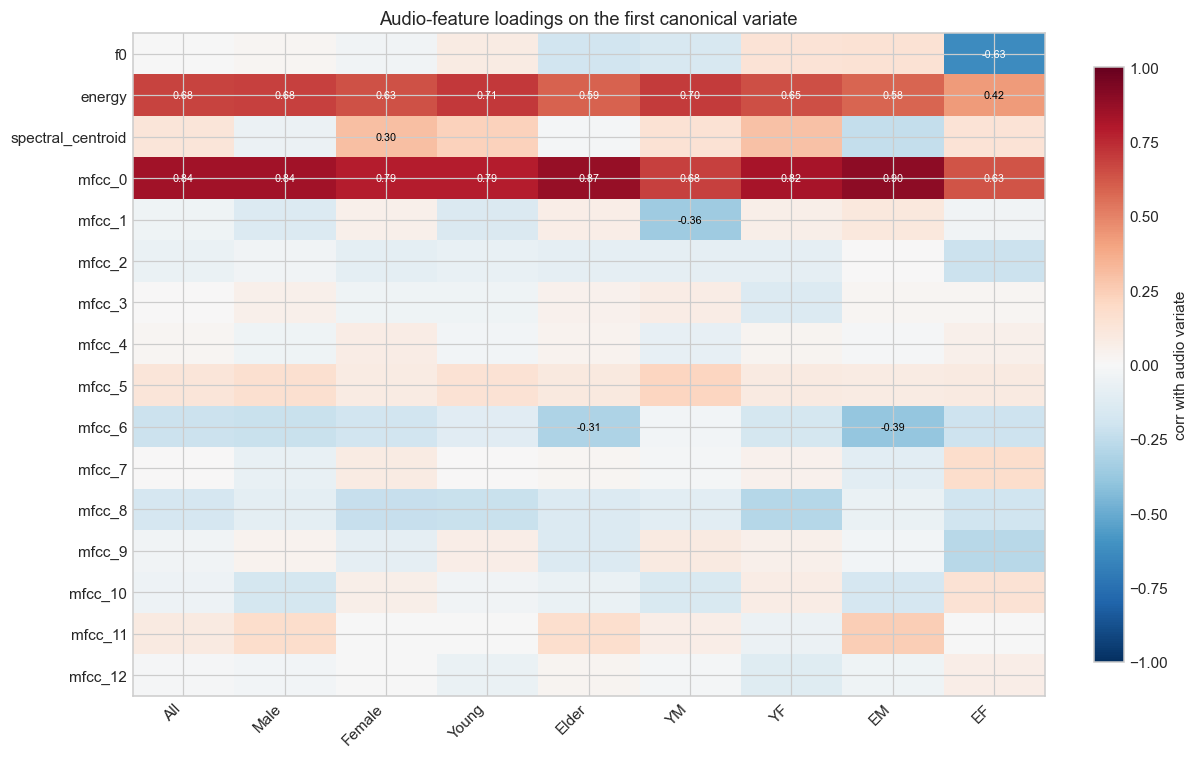

OEP loadings (All): {'delta_vcw': 0.99, 'flow_cw': -0.08, 'pct_rc': -0.64}


In [3]:
piv = pd.DataFrame({s: {f: cca_res[s]['audio_loadings'][f] for f in AUDIO} for s in strata}).reindex(AUDIO)
fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(piv.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=45, ha='right')
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if abs(v) > 0.3:
            ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=7,
                    color='white' if abs(v) > 0.55 else 'black')
ax.set_title('Audio-feature loadings on the first canonical variate')
fig.colorbar(im, ax=ax, fraction=0.03, label='corr with audio variate')
plt.tight_layout(); plt.show()
# OEP side, All stratum
print('OEP loadings (All):', {k: round(v, 2) for k, v in cca_res['All']['oep_loadings'].items()})

**Observations:**\
Sustained phonation, within-subject z-scored.\
The audio canonical variate is dominated by **MFCC-0 (≈ +0.84)** and **energy (≈ +0.68)**: overall spectral level / loudness.\
`f0` and the higher MFCCs contribute little, and the pattern is consistent across strata.\
So the audio side that couples to respiration is loudness, not pitch, the same carrier the FRC-state classifier found in notebook n°6.

## 3. PLS: predict %RC from the audio block, per stratum
Leave-subjects-out CV R² for the whole audio block predicting `%RC` (the multivariate version of notebook n°5's per-feature Ridge).

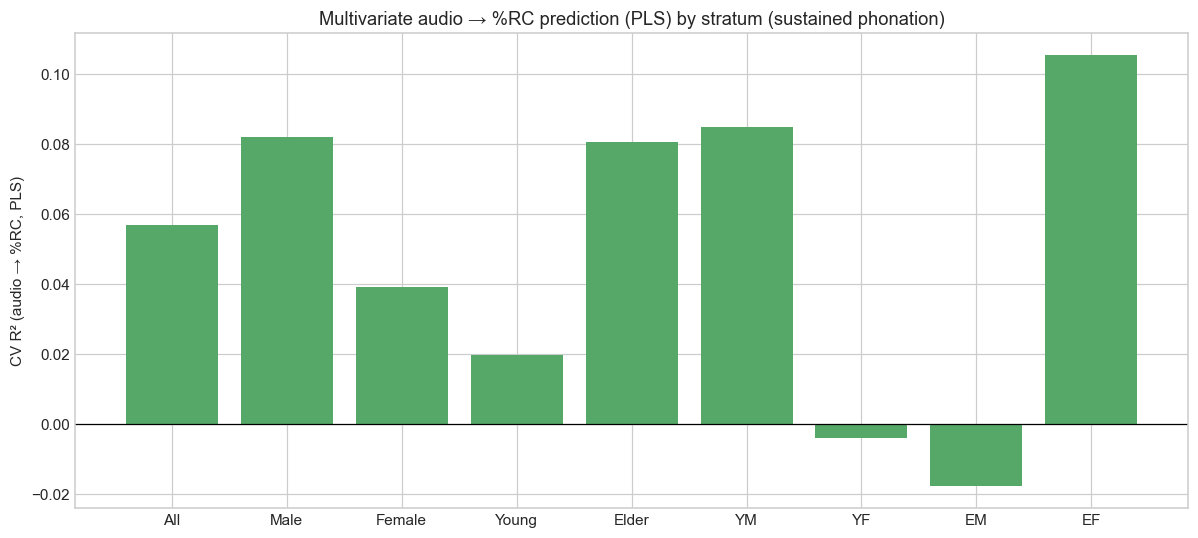

audio → %RC CV R²: {'All': 0.057, 'Male': 0.082, 'Female': 0.039, 'Young': 0.02, 'Elder': 0.081, 'YM': 0.085, 'YF': -0.004, 'EM': -0.018, 'EF': 0.105}


In [4]:
pls_res = {s: pls_cv(F, stratum_index(F, s)) for s in STRATA_ORDER}
pls_res = {s: r for s, r in pls_res.items() if r is not None}
ps = list(pls_res)
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(len(ps)), [pls_res[s]['r2_cv'] for s in ps], color='#55a868')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(ps))); ax.set_xticklabels(ps)
ax.set_ylabel('CV R² (audio → %RC, PLS)')
ax.set_title('Multivariate audio → %RC prediction (PLS) by stratum (sustained phonation)')
plt.tight_layout(); plt.show()
print('audio → %RC CV R²:', {s: round(pls_res[s]['r2_cv'], 3) for s in ps})

**Observations:**\
Sustained phonation; audio block → `%RC`; leave-subjects-out CV.\
Multivariate PLS predicts within-subject `%RC` weakly but positively (CV R² ≈ 0.06 overall, up to ≈ 0.10 in elderly females, young males, and the elderly/male aggregates).\
This edges out the per-feature Ridge of notebook n°5 (which was negative), so combining features helps a little.\
It is near-chance in young females and elderly males; continuous `%RC` stays hard to predict frame-by-frame, consistent with notebook n°5.

## Recap
The multivariate tools (CCA, PLS) confirm and sharpen the pairwise picture rather than overturning it. There is a genuine, subject-validated audio↔respiratory coupling (canonical r ≈ 0.39), it is **low-dimensional and carried by loudness / spectral level** (MFCC-0, energy), and audio → `%RC` is only weakly predictive (CV R² ≈ 0.06 to 0.10).

Practical consequence for M3/M4: the readable respiratory signal in voice is a loudness/level effect, best posed as the **binary FRC-state decode** of notebook n°6 (which reaches ≈ 0.70 per frame, ≈ 0.96 at the breath scale) rather than a continuous `%RC` regression. A sparse-CCA or kernel/Deep-CCA refinement is worth trying only as a ceiling check; the linear multivariate ceiling here is modest.

To regenerate the CSVs and PDF figures from the command line:

```bash
python scripts/analyze_multivariate_coupling.py --paired-dir data_target/healthy_subjects/paired     --metadata data_root/healthy_subjects/subjects_metadata.csv --output-dir data_target/healthy_subjects/M3_multivariate
```